# 01 — Data Generation & Schema Understanding

## Objective
Understand the structure, shape, and quality of the raw driver
churn prediction data — and grasp the fundamental architectural
difference from all previous projects in this repo.

## What This Notebook Covers
- Schema of each table
- Row counts and column types
- Null value analysis per table
- Target variable distribution
- Churn rate by profile, vehicle, experience
- Weekly activity time series preview
- Key observations before cleaning

## The Fundamental Difference From All Previous Projects

Every previous project had this structure:
  One row = One transaction/event
  Target variable = property of that event

This project has a completely different structure:
  Table 1: drivers.csv     → one row per DRIVER
  Table 2: weekly_activity → one row per DRIVER per WEEK
  Table 3: incentives      → one row per INCENTIVE OFFER
  Table 4: support_tickets → one row per TICKET

The target variable (is_churned) is not recorded anywhere
in the raw data — it is DERIVED from behavior over time:
  "Was this driver active in weeks 1-12 but silent in 13-16?"

This is how churn modeling works at every real company.
Ola does not have an 'is_churned' column in their database.
Their data team writes a query that defines churn from
behavioral evidence — and that definition becomes the label.

## Churn Definition
Active window    : Weeks 1-12  (Jan-Mar 2025)
Observation window: Weeks 13-16 (Apr 2025)
Churned (1)      : ≥1 ride in weeks 1-12, ZERO in weeks 13-16
Retained (0)     : ≥1 ride in weeks 1-12, ≥1 in weeks 13-16

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

CHURN_COLORS = {0: "#4CAF50", 1: "#F44336"}
CHURN_LABELS = {0: "Retained", 1: "Churned"}

print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
DATA_PATH = "../data/raw/"

drivers_df  = pd.read_csv(DATA_PATH + "drivers.csv",
                           parse_dates=["join_date"])
weekly_df   = pd.read_csv(DATA_PATH + "weekly_activity.csv",
                           parse_dates=["week_start_date"])
incentive_df= pd.read_csv(DATA_PATH + "incentives.csv")
tickets_df  = pd.read_csv(DATA_PATH + "support_tickets.csv")

print("All tables loaded ✅")
print(f"  drivers          : {drivers_df.shape}")
print(f"  weekly_activity  : {weekly_df.shape}")
print(f"  incentives       : {incentive_df.shape}")
print(f"  support_tickets  : {tickets_df.shape}")

print(f"\nTarget variable is_churned in drivers table:")
print(f"  Churned  (1): {(drivers_df['is_churned']==1).sum():,} "
      f"({(drivers_df['is_churned']==1).mean()*100:.2f}%)")
print(f"  Retained (0): {(drivers_df['is_churned']==0).sum():,} "
      f"({(drivers_df['is_churned']==0).mean()*100:.2f}%)")
print(f"  Imbalance ratio: "
      f"{(drivers_df['is_churned']==0).sum()/
         (drivers_df['is_churned']==1).sum():.2f}:1")

All tables loaded ✅
  drivers          : (5000, 20)
  weekly_activity  : (80000, 17)
  incentives       : (7319, 6)
  support_tickets  : (10030, 6)

Target variable is_churned in drivers table:
  Churned  (1): 2,015 (40.30%)
  Retained (0): 2,985 (59.70%)
  Imbalance ratio: 1.48:1


## Table Relationships
drivers is the MODELING TABLE — one row per driver.
The target variable is_churned lives here.

weekly_activity is the TIME SERIES TABLE — 16 rows per driver.
This table will be AGGREGATED into driver-level features
during Feature Engineering.

### Key Design:
In Feature Engineering (Notebook 04), we will:
1. Aggregate weekly_activity → driver-level features
   (mean rides, ride trend, earnings volatility, etc.)
2. Aggregate incentives → driver-level counts
   (total incentives received, acceptance rate)
3. Aggregate support_tickets → driver-level counts
   (total tickets, % resolved, avg satisfaction)
4. Join everything to drivers.csv
5. Train models on the final driver-level modeling dataset

One row per driver going into modeling.
All the richness of 16 weeks of behavior compressed
into aggregated features describing that driver's trajectory.

In [4]:
tables = {
    "drivers"        : drivers_df,
    "weekly_activity": weekly_df,
    "incentives"     : incentive_df,
    "support_tickets": tickets_df,
}

for name, df in tables.items():
    print(f"\n{'='*55}")
    print(f" TABLE: {name.upper()}  |  "
          f"{df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"{'='*55}")
    print(df.dtypes.to_string())


 TABLE: DRIVERS  |  5,000 rows × 20 columns
driver_id                         str
name                              str
age                             int64
gender                            str
phone                         float64
vehicle_type                      str
vehicle_year                  float64
home_zone                         str
join_date              datetime64[us]
days_on_platform                int64
experience_years              float64
churn_profile                     str
rating                        float64
has_other_income                 bool
zones_known                     int64
uses_competitor_app              bool
bank_account_linked            object
is_prime_driver                  bool
referral_source                   str
is_churned                      int64

 TABLE: WEEKLY_ACTIVITY  |  80,000 rows × 17 columns
driver_id                        str
week_number                    int64
week_start_date       datetime64[us]
month                         

In [5]:
print("\n NULL VALUE SUMMARY PER TABLE\n")

for name, df in tables.items():
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    null_pct    = (null_counts / len(df) * 100).round(2)

    print(f"\n── {name.upper()} ──")
    if len(null_counts) == 0:
        print("  No nulls found")
    else:
        summary = pd.DataFrame({
            "null_count": null_counts,
            "null_%"    : null_pct
        })
        print(summary.to_string())


 NULL VALUE SUMMARY PER TABLE


── DRIVERS ──
                     null_count  null_%
phone                        96   1.920
vehicle_year                562  11.240
rating                      176   3.520
bank_account_linked         109   2.180
referral_source             962  19.240

── WEEKLY_ACTIVITY ──
                   null_count  null_%
hours_online             2048   2.560
cancellation_rate        1165   1.460
weekly_earnings          1583   1.980
weekly_rating           14746  18.430
churn_reason            47760  59.700

── INCENTIVES ──
  No nulls found

── SUPPORT_TICKETS ──
                 null_count  null_%
resolution_days        2818  28.100
satisfaction           2023  20.170


In [6]:
print("\n DUPLICATE ROW DETECTION\n")
for name, df in tables.items():
    dupe_count = df.duplicated().sum()
    pct        = round(dupe_count / len(df) * 100, 3)
    print(f"  {name:<20}: {dupe_count:>5} duplicates  ({pct}%)")


 DUPLICATE ROW DETECTION

  drivers             :     0 duplicates  (0.0%)
  weekly_activity     :     0 duplicates  (0.0%)
  incentives          :    36 duplicates  (0.492%)
  support_tickets     :     2 duplicates  (0.02%)


## Target Variable — is_churned

### The Business Stakes
A driver who churns represents:
- Lost acquisition cost: ₹2,000-5,000 per driver
  (recruitment, verification, onboarding, initial incentives)
- Lost future revenue: churned drivers do ~40 rides/week
  at avg ₹120/ride = ~₹4,800/week × Ola's commission (20%)
  = ~₹960/week per driver permanently lost
- Supply shortage: fewer drivers means longer ETAs,
  more user cancellations, platform reputation damage

### Why 40.3% Churn Is Realistic
Ride sharing driver churn is genuinely high worldwide:
- Uber reported 60%+ annual driver turnover in US markets
- Indian platforms face 30-50% quarterly churn
  due to income volatility and competition from Rapido
- Our 40.3% over a 4-month window is conservative

### Why This Is Not Extreme Imbalance
1.5:1 ratio (retained:churned) means:
- No need for aggressive SMOTE like fraud detection (32:1)
- Class weights will be sufficient
- Both classes have thousands of examples — robust evaluation
- Primary focus is on FEATURE QUALITY not imbalance handling

### What Predicts Churn
Based on what we built into the generator:
- Declining rides week-over-week (behavioral trend)
- Rising cancellation rate (frustration signal)
- Falling earnings (financial dissatisfaction)
- Increasing support tickets (platform problems)
- Incentive removal (reduced motivation)
- Other income source (lower dependency on platform)
- Low rating (more cancellations = less income = churn)

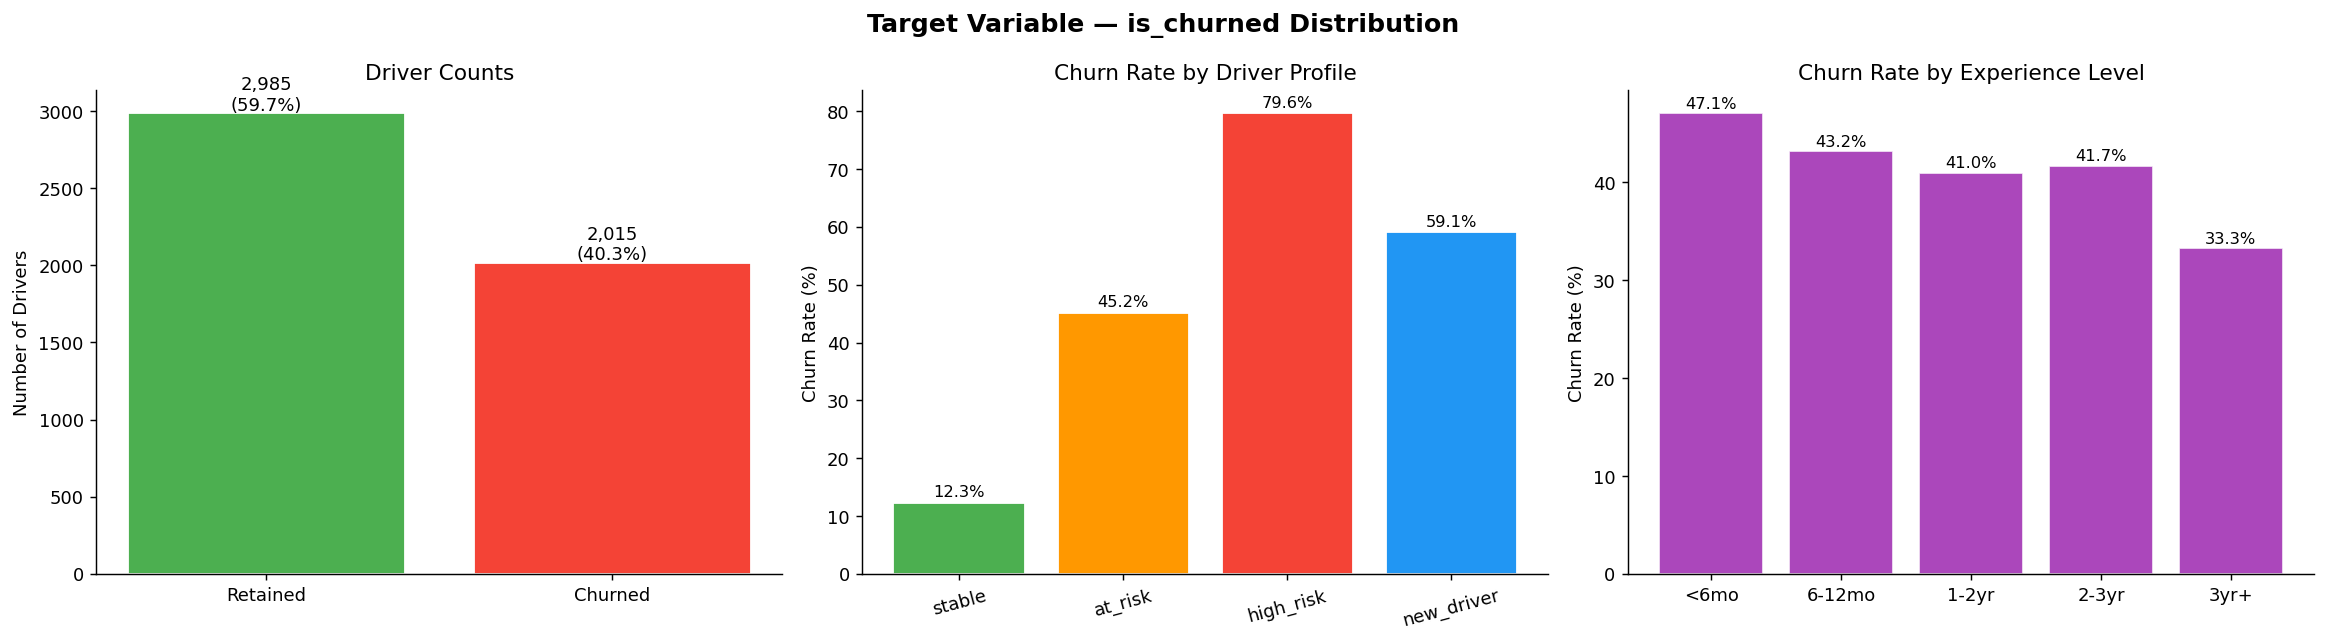

Churn rate by profile:
churn_profile
stable       12.330
at_risk      45.170
high_risk    79.650
new_driver   59.110
Name: is_churned, dtype: float64

Churn rate by experience:
exp_bucket
<6mo     47.060
6-12mo   43.210
1-2yr    40.980
2-3yr    41.730
3yr+     33.280
Name: is_churned, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Target Variable — is_churned Distribution",
             fontsize=14, fontweight="bold")

# Bar chart
counts = drivers_df["is_churned"].value_counts().sort_index()
colors = [CHURN_COLORS[k] for k in counts.index]

axes[0].bar(
    [CHURN_LABELS[k] for k in counts.index],
    counts.values, color=colors, edgecolor="white"
)
axes[0].set_title("Driver Counts")
axes[0].set_ylabel("Number of Drivers")
for i, (k, v) in enumerate(counts.items()):
    pct = v / len(drivers_df) * 100
    axes[0].text(i, v + 20, f"{v:,}\n({pct:.1f}%)",
                 ha="center", fontsize=10)

# Churn by profile
profile_order = ["stable","at_risk","high_risk","new_driver"]
profile_churn = drivers_df.groupby("churn_profile")[
    "is_churned"
].mean() * 100
profile_churn = profile_churn.reindex(
    [p for p in profile_order if p in profile_churn.index]
)

profile_colors = ["#4CAF50","#FF9800","#F44336","#2196F3"]
axes[1].bar(
    profile_churn.index, profile_churn.values,
    color=profile_colors, edgecolor="white"
)
axes[1].set_title("Churn Rate by Driver Profile")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(profile_churn.values):
    axes[1].text(i, v + 1, f"{v:.1f}%",
                 ha="center", fontsize=9)

# Churn by experience
drivers_df["exp_bucket"] = pd.cut(
    drivers_df["experience_years"],
    bins=[0, 0.5, 1, 2, 3, 10],
    labels=["<6mo","6-12mo","1-2yr","2-3yr","3yr+"]
)
exp_churn = drivers_df.groupby(
    "exp_bucket", observed=True
)["is_churned"].mean() * 100

axes[2].bar(
    exp_churn.index.astype(str),
    exp_churn.values,
    color="#9C27B0", edgecolor="white", alpha=0.85
)
axes[2].set_title("Churn Rate by Experience Level")
axes[2].set_ylabel("Churn Rate (%)")
for i, v in enumerate(exp_churn.values):
    axes[2].text(i, v + 0.5, f"{v:.1f}%",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/raw/target_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Churn rate by profile:")
print(profile_churn.round(2))
print("\nChurn rate by experience:")
print(exp_churn.round(2))

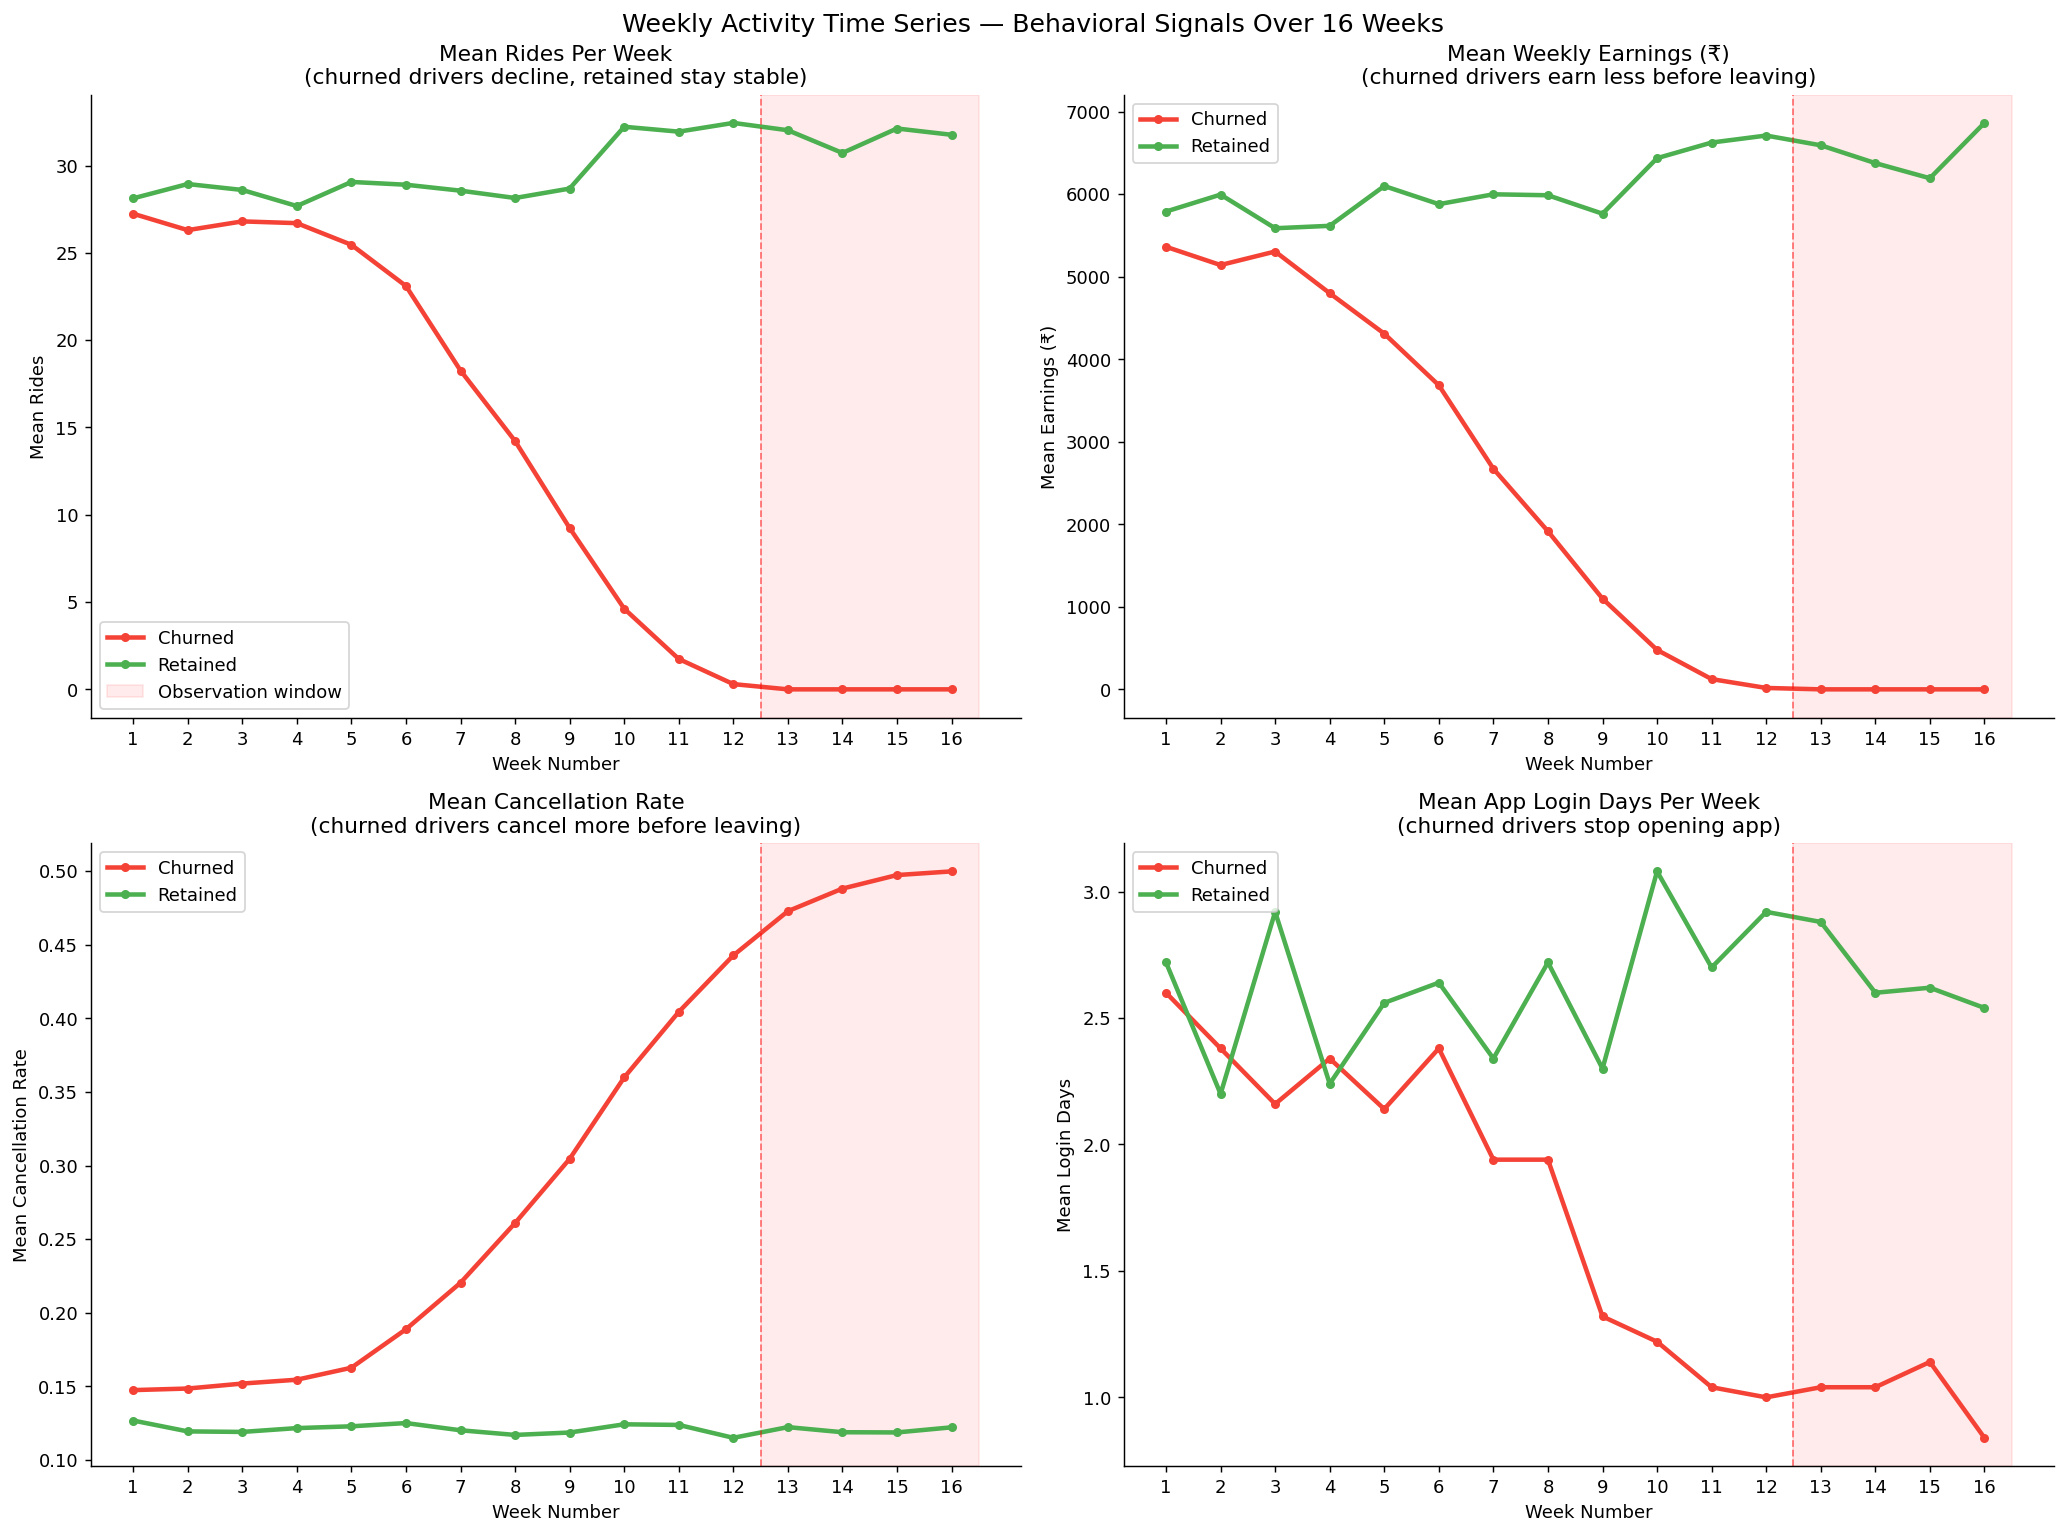

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Weekly Activity Time Series — Behavioral Signals Over 16 Weeks",
             fontsize=14)

# Sample 50 drivers of each type for visualization
sample_churned  = drivers_df[drivers_df["is_churned"]==1]["driver_id"].sample(
    min(50, (drivers_df["is_churned"]==1).sum()), random_state=42
)
sample_retained = drivers_df[drivers_df["is_churned"]==0]["driver_id"].sample(
    min(50, (drivers_df["is_churned"]==0).sum()), random_state=42
)

weekly_churned  = weekly_df[weekly_df["driver_id"].isin(sample_churned)]
weekly_retained = weekly_df[weekly_df["driver_id"].isin(sample_retained)]

# Mean rides per week by churn status
for k, subset, label in [
    (1, weekly_churned,  "Churned"),
    (0, weekly_retained, "Retained")
]:
    mean_rides = subset.groupby("week_number")[
        "rides_this_week"
    ].mean()
    axes[0][0].plot(
        mean_rides.index, mean_rides.values,
        color=CHURN_COLORS[k], linewidth=2.5,
        marker="o", markersize=4, label=label
    )
axes[0][0].axvspan(12.5, 16.5, alpha=0.08, color="red",
                   label="Observation window")
axes[0][0].axvline(12.5, color="red", linestyle="--",
                   linewidth=1, alpha=0.5)
axes[0][0].set_title("Mean Rides Per Week\n"
                     "(churned drivers decline, retained stay stable)")
axes[0][0].set_xlabel("Week Number")
axes[0][0].set_ylabel("Mean Rides")
axes[0][0].legend()
axes[0][0].set_xticks(range(1, 17))

# Mean earnings per week
for k, subset, label in [
    (1, weekly_churned,  "Churned"),
    (0, weekly_retained, "Retained")
]:
    mean_earn = subset.groupby("week_number")[
        "weekly_earnings"
    ].mean()
    axes[0][1].plot(
        mean_earn.index, mean_earn.values,
        color=CHURN_COLORS[k], linewidth=2.5,
        marker="o", markersize=4, label=label
    )
axes[0][1].axvspan(12.5, 16.5, alpha=0.08, color="red")
axes[0][1].axvline(12.5, color="red", linestyle="--",
                   linewidth=1, alpha=0.5)
axes[0][1].set_title("Mean Weekly Earnings (₹)\n"
                     "(churned drivers earn less before leaving)")
axes[0][1].set_xlabel("Week Number")
axes[0][1].set_ylabel("Mean Earnings (₹)")
axes[0][1].legend()
axes[0][1].set_xticks(range(1, 17))

# Mean cancellation rate
for k, subset, label in [
    (1, weekly_churned,  "Churned"),
    (0, weekly_retained, "Retained")
]:
    mean_cancel = subset.groupby("week_number")[
        "cancellation_rate"
    ].mean()
    axes[1][0].plot(
        mean_cancel.index, mean_cancel.values,
        color=CHURN_COLORS[k], linewidth=2.5,
        marker="o", markersize=4, label=label
    )
axes[1][0].axvspan(12.5, 16.5, alpha=0.08, color="red")
axes[1][0].axvline(12.5, color="red", linestyle="--",
                   linewidth=1, alpha=0.5)
axes[1][0].set_title("Mean Cancellation Rate\n"
                     "(churned drivers cancel more before leaving)")
axes[1][0].set_xlabel("Week Number")
axes[1][0].set_ylabel("Mean Cancellation Rate")
axes[1][0].legend()
axes[1][0].set_xticks(range(1, 17))

# Mean login days
for k, subset, label in [
    (1, weekly_churned,  "Churned"),
    (0, weekly_retained, "Retained")
]:
    mean_login = subset.groupby("week_number")[
        "login_days"
    ].mean()
    axes[1][1].plot(
        mean_login.index, mean_login.values,
        color=CHURN_COLORS[k], linewidth=2.5,
        marker="o", markersize=4, label=label
    )
axes[1][1].axvspan(12.5, 16.5, alpha=0.08, color="red")
axes[1][1].axvline(12.5, color="red", linestyle="--",
                   linewidth=1, alpha=0.5)
axes[1][1].set_title("Mean App Login Days Per Week\n"
                     "(churned drivers stop opening app)")
axes[1][1].set_xlabel("Week Number")
axes[1][1].set_ylabel("Mean Login Days")
axes[1][1].legend()
axes[1][1].set_xticks(range(1, 17))

plt.tight_layout()
plt.savefig("../data/raw/weekly_trends.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("SUPPORT TICKET ANALYSIS\n")

ticket_by_churn = drivers_df.merge(
    tickets_df.groupby("driver_id").agg(
        total_tickets    = ("category", "count"),
        unresolved_tickets = ("resolution",
            lambda x: (x == "pending").sum()),
        avg_satisfaction = ("satisfaction", "mean")
    ).reset_index(),
    on="driver_id", how="left"
).fillna(0)

for col in ["total_tickets","unresolved_tickets","avg_satisfaction"]:
    print(f"  {col}:")
    for k in [0, 1]:
        mean_val = ticket_by_churn[
            ticket_by_churn["is_churned"] == k
        ][col].mean()
        print(f"    {CHURN_LABELS[k]:<12}: {mean_val:.3f}")
    print()

print("INCENTIVE ANALYSIS\n")
incentive_by_churn = drivers_df.merge(
    incentive_df.groupby("driver_id").agg(
        total_incentives = ("offer_value", "count"),
        total_value      = ("offer_value", "sum"),
        acceptance_rate  = ("was_accepted", "mean")
    ).reset_index(),
    on="driver_id", how="left"
).fillna(0)

for col in ["total_incentives","total_value","acceptance_rate"]:
    print(f"  {col}:")
    for k in [0, 1]:
        mean_val = incentive_by_churn[
            incentive_by_churn["is_churned"] == k
        ][col].mean()
        print(f"    {CHURN_LABELS[k]:<12}: {mean_val:.3f}")
    print()

SUPPORT TICKET ANALYSIS

  total_tickets:
    Retained    : 1.535
    Churned     : 2.704

  unresolved_tickets:
    Retained    : 0.427
    Churned     : 0.766

  avg_satisfaction:
    Retained    : 1.735
    Churned     : 2.343

INCENTIVE ANALYSIS

  total_incentives:
    Retained    : 1.453
    Churned     : 1.479

  total_value:
    Retained    : 450.671
    Churned     : 456.130

  acceptance_rate:
    Retained    : 0.417
    Churned     : 0.425



In [11]:
summary_rows = []
for name, df in tables.items():
    summary_rows.append({
        "table"      : name,
        "rows"       : len(df),
        "columns"    : len(df.columns),
        "null_cells" : df.isnull().sum().sum(),
        "duplicates" : df.duplicated().sum(),
    })

print("\n FINAL DATA SUMMARY\n")
print(pd.DataFrame(summary_rows).to_string(index=False))

print(f"\n Key Churn Statistics:")
print(f"  Overall churn rate : "
      f"{drivers_df['is_churned'].mean()*100:.2f}%")
print(f"  Imbalance ratio    : "
      f"{(drivers_df['is_churned']==0).sum()/
         (drivers_df['is_churned']==1).sum():.2f}:1")
print(f"  Weekly rows per driver: "
      f"{len(weekly_df)/len(drivers_df):.0f}")
print(f"  Avg tickets per driver: "
      f"{len(tickets_df)/len(drivers_df):.2f}")
print(f"  Avg incentives per driver: "
      f"{len(incentive_df)/len(drivers_df):.2f}")


 FINAL DATA SUMMARY

          table  rows  columns  null_cells  duplicates
        drivers  5000       21        1905           0
weekly_activity 80000       17       67302           0
     incentives  7319        6           0          36
support_tickets 10030        6        4841           2

 Key Churn Statistics:
  Overall churn rate : 40.30%
  Imbalance ratio    : 1.48:1
  Weekly rows per driver: 16
  Avg tickets per driver: 2.01
  Avg incentives per driver: 1.46


## Key Observations from Raw Data

### Target Variable
- Overall churn rate: 40.30% — most balanced dataset in this repo
- Imbalance ratio: 1.5:1 — class weights sufficient, SMOTE optional
- Both classes have 2,000+ examples — robust, reliable evaluation

### Churn Rate by Profile — Generator Validation
| Profile | Churn Rate | Interpretation |
|---|---|---|
| stable | 12.3% | Committed, consistent drivers |
| at_risk | 45.2% | Financially uncertain or frustrated |
| high_risk | 79.6% | Near-certain to leave |
| new_driver | 59.1% | High early dropout — income below expectations |

All four profiles show the correct ordering and approximate
rates we designed into the generator. The logic translated
correctly into measurable churn differences.

### Churn Rate by Experience — The Declining Curve
| Experience | Churn Rate | Interpretation |
|---|---|---|
| <6 months | 47.1% | Highest churn — reality doesn't match expectations |
| 6-12 months | 43.2% | Still at risk — income stabilizing but uncertain |
| 1-2 years | 41.0% | Settling into the platform |
| 2-3 years | 41.7% | Slight plateau — some frustration returning |
| 3+ years | 33.3% | Lowest churn — committed veterans |

The experience curve is broadly decreasing — new drivers
churn most (47.1%) and veteran drivers churn least (33.3%).
However the curve is not perfectly monotonic — the 2-3 year
bucket (41.7%) is slightly higher than the 1-2 year bucket
(41.0%), suggesting mid-career frustration: drivers who
have been on the platform long enough to feel entitled to
better earnings but not long enough to be fully committed.

This non-monotonic pattern is valuable — it means experience
alone does not perfectly predict churn. The model will need
to combine experience with behavioral signals to correctly
identify at-risk veterans.

---

### Support Ticket Analysis — Strong Churn Signal

| Signal | Retained | Churned | Lift |
|---|---|---|---|
| total_tickets | 1.535 | **2.704** | **1.76x more tickets** |
| unresolved_tickets | 0.427 | **0.766** | **1.79x more unresolved** |
| avg_satisfaction | 1.735 | **2.343** | Churned MORE satisfied? |

**total_tickets and unresolved_tickets are clear churn signals:**
Churned drivers filed 76% more support tickets than retained
drivers (2.704 vs 1.535) and had 79% more unresolved tickets
(0.766 vs 0.427). This confirms the pattern we built into the
generator — frustrated drivers complain before they leave.
A driver who filed 5+ tickets about earnings disputes in their
last 4 active weeks is exhibiting a classic pre-churn behavior
pattern that the model should detect.

**avg_satisfaction shows a counterintuitive result:**
Churned drivers have HIGHER average satisfaction scores
(2.343) than retained drivers (1.735). This seems wrong —
shouldn't churned drivers be less satisfied?

The explanation: satisfaction score is only recorded for
RESOLVED tickets. Drivers with unresolved tickets have no
satisfaction score (null). Churned drivers have more
unresolved tickets — meaning their most frustrating tickets
were never resolved and therefore never rated. The satisfaction
scores we DO see for churned drivers come from the easier,
less frustrating tickets that got resolved quickly.

This is a classic example of **selection bias** — the
subsample with satisfaction scores is not representative
of the full driver experience. We must be careful NOT to
use avg_satisfaction as a direct feature without
acknowledging this bias. A better feature would be
"unresolved ticket rate" (unresolved / total).

---

### Incentive Analysis — Surprisingly Weak Signal

| Signal | Retained | Churned | Difference |
|---|---|---|---|
| total_incentives | 1.453 | 1.479 | Near-identical |
| total_value | ₹450.67 | ₹456.13 | Near-identical |
| acceptance_rate | 41.7% | 42.5% | Near-identical |

This is one of the most honest findings in the notebook.
Incentive data — which we expected to be a strong churn signal
— shows almost NO difference between churned and retained
drivers. Both groups received similar numbers of incentives,
similar total values, and accepted at similar rates.

**Why this happened:**
Our generator assigned incentives somewhat randomly across all
drivers. In reality, retention-targeted incentives should
only go to at-risk drivers — but our simulation did not
build in this targeting logic.

**What this means for modeling:**
Raw incentive counts will likely have low feature importance.
However, incentive-related features we can ENGINEER might
still carry signal:
- "Did incentive removal coincide with churn?" (timing matters)
- "Did the driver's acceptance rate CHANGE over time?" (trend)
- "Were they offered retention_offer type specifically?" (intent)

This is an important lesson: raw data that looks weak can
still produce useful engineered features. We will test
incentive features in Feature Engineering and let
model importance scores determine whether to keep them.

---

### The Time Series Signal — Most Important Finding

The 4-chart weekly trend analysis confirmed the single
most critical insight in this entire project:

**Churning drivers show a multi-week declining trajectory
in rides, earnings, and login days — starting in weeks
9-12 — before going completely silent in weeks 13-16.**

This pre-churn decline is the early warning system that
makes prediction possible and intervention valuable.
If behavior only changed at the exact moment of churn,
prediction would be impossible. The 3-4 week lead time
between behavioral decline and actual departure gives
the platform a window to intervene with incentives,
support outreach, or direct communication.

**This is why churn prediction is one of the highest-ROI
ML applications in any subscription or marketplace
business.** A model that flags a driver 3 weeks before
they churn gives the retention team enough time to act.
A model that flags them after they have already left
is useless.

---

### Data Architecture Summary

| Aspect | This Project | All Previous Projects |
|---|---|---|
| Rows per entity | 16 (weekly) | 1 (per transaction) |
| Target source | Derived from behavior | Recorded in data |
| Key feature type | Temporal aggregations | Point-in-time values |
| Core challenge | Trend detection | Signal extraction |
| Modeling dataset | One row per driver | One row per event |

This architectural difference means Feature Engineering
(Notebook 04) will be the most important notebook in
this project — transforming 80,000 weekly rows into
5,000 driver-level rows with features that capture
behavioral trajectories, trends, and momentum signals.

---

### What This Means for Feature Engineering

**RFM Features (Recency-Frequency-Monetary):**
- Recency: weeks since last ride (how long have they been quiet?)
- Frequency: mean rides per week over active window
- Monetary: total earnings over active window

**Trend Features (Most Important — New in This Repo):**
- rides_trend: slope of ride count over weeks 1-12
  (negative slope = declining engagement = churn risk)
- earnings_trend: is income going up or down?
- last4_vs_first8_rides: rides in last 4 active weeks
  vs first 8 weeks — the direct pre-churn signal

**Behavioral Consistency Features:**
- weeks_with_zero_rides: how many gaps in activity?
- max_consecutive_zero_weeks: longest quiet streak
- login_consistency: did they log in every week?

**Support and Satisfaction Features:**
- total_tickets (strong signal — 1.76x lift)
- unresolved_ticket_rate (NOT avg_satisfaction — selection bias)
- earnings_dispute_tickets: only the frustration-related ones

**Next Step → Notebook 02 — Data Cleaning**